## Questão 7 - Previsão de demanda

### Cenário

O Sr. Almir está furioso. No último verão, o estoque de "Coletes Salva-Vidas' acabou em 10 dias, e a
empresa perdeu milhares de reais em vendas. Por outro lado, compraram 'Ancoras" demais e elas
estão enferrujando no galpão. 

Gabriel Santos, o Tech Lead, disse que não da mais para confiar no *feeling*. Ele quer um modelo preditivo que diga exatamente quantas unidades venderemos no próximo mês para ajustar as compras com fornecedores.

### Premissas obrigatórias:

- O período de treino deve incluir dados **até** 31/12/2023.
- O período de teste deve ser todo o mês de Janeiro de 2024.
- A previsão deve ser feita em base diária.
- Não é permitido utilizar dados futuros no treino (data leakage).
- Considere apenas o produto: "Motor de Popa Yamaha Evo Dash 155HP"

### Tarefa:

1. Utilize o dataset `vendas_2023_2024.csv`
2. Construa um modelo baseline simples, utilizando: 
    * Média móvel dos últimos 7 dias de vendas (considerando apenas dados anteriores à data prevista).
3. Gere a previsão diária de vendas para Janeiro de 2024.
4. Compare as previsões com os valores reais do período de teste utilizando a métrica: `MAE - Mean Absolute Error`
5. Responda objetivamente:
    * O baseline é adequado para esse produto?
    * Cite uma limitação desse método.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error

In [10]:
# Carregando os datastes
vendas = pd.read_csv('../datasets/raw/vendas_2023_2024.csv')
produtos = pd.read_csv('../datasets/raw/produtos_raw.csv')

# Tratamento dos valores (sale_date)
def parse_date(date_str):
    try:
        return pd.to_datetime(date_str, format='%Y-%m-%d')
    except ValueError:
        try:
            return pd.to_datetime(date_str, format='%d-%m-%Y')
        except ValueError:
            return pd.NaT

vendas['sale_date'] = vendas['sale_date'].apply(parse_date)

display(vendas)

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.00,2023-09-10
1,1,3,136,9,16873.90,2024-09-15
2,2,25,139,7,9475.30,2024-08-13
3,4,20,23,5,55893.00,2023-02-03
4,5,8,57,4,451403.90,2024-02-12
...,...,...,...,...,...,...
9890,9995,30,139,6,8549.00,2023-03-11
9891,9996,9,111,7,28497.15,2023-09-17
9892,9997,38,123,2,5276.30,2023-06-20
9893,9998,33,97,6,771409.50,2024-10-23


In [11]:
# Tratamento de dados do datasets produtos
# Correção de inconsistências na coluna 'actual_category'
def normalizar_categoria(categoria):
    cat_limpa = str(categoria).strip().lower().replace(' ', '')
    if 'eletr' in cat_limpa:
        return 'Eletrônicos'
    elif 'prop' in cat_limpa:
        return 'Propulsão'
    elif 'anc' in cat_limpa or 'enc' in cat_limpa:
        return 'Ancoragem'
    else:
        return categoria.title()

# Aplicar a função de normalização na coluna 'actual_category'    
produtos['actual_category'] = produtos['actual_category'].apply(normalizar_categoria)

# Verificar as categorias únicas após normalização
print(f" Categorias: {produtos['actual_category'].unique()}")

# Converter a coluna price para numérica, removendo o símbolo de moeda e convertendo vírgulas para pontos
produtos['price'] = produtos['price'].str.replace('R$', '', regex=False)
produtos['price'] = produtos['price'].str.replace(',', '.', regex=False)
produtos['price'] = pd.to_numeric(produtos['price'])

# Remover registros duplicados
produtos.drop_duplicates(inplace=True)

# Renomear a coluna 'code' para 'id_product' para melhor clareza e consistência com o nome do arquivo
produtos.rename(columns={'code': 'id_product'}, inplace=True)
print(f" Coluna 'code' renomeada para 'id_product'.")

display(produtos)


 Categorias: ['Eletrônicos' 'Propulsão' 'Ancoragem']
 Coluna 'code' renomeada para 'id_product'.


,name,price,id_product,actual_category
0,Transponder AIS Maré Magnum,33122.52,1,Eletrônicos
1,Transponder Furuno Marlin,13998.15,2,Eletrônicos
2,Radar Furuno Pulse Leviathan,9024.19,3,Eletrônicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,Eletrônicos
4,Piloto Automático Furuno Storm,23669.01,5,Eletrônicos
...,...,...,...,...
152,Corrente Delta Vox Ion,495.98,146,Ancoragem
153,Corrente Danforth Force Leviathan Impulse,3030.08,147,Ancoragem
154,Âncora Delta Force Barracuda Mako,4785.56,148,Ancoragem
155,Cabo de Nylon Bruce Core,1163.62,149,Ancoragem


In [12]:
# Encontrando produto específico
resultado = produtos[produtos['name'].str.contains("155HP", case=False, na=False)]
print(resultado)

                                   name      price  id_product actual_category
54  Motor de Popa Yamaha Evo Dash 155HP  121534.82          54       Propulsão


In [15]:
# Unindo tabelas para filtrar pelo id do produto
id = 54 # id do produto
df = pd.merge(vendas, produtos, left_on='id_product', right_on='id_product')
df = df[df['id_product'] == id].copy()

display(df)

,id,id_client,id_product,qtd,total,sale_date,name,price,actual_category
46,48,13,54,15,1823022.00,2024-05-30,Motor de Popa Yamaha Evo Dash 155HP,121534.82,Propulsão
53,55,35,54,3,346373.80,2024-11-24,Motor de Popa Yamaha Evo Dash 155HP,121534.82,Propulsão
71,74,45,54,11,1270038.85,2024-09-25,Motor de Popa Yamaha Evo Dash 155HP,121534.82,Propulsão
442,451,42,54,13,1500955.35,2024-02-19,Motor de Popa Yamaha Evo Dash 155HP,121534.82,Propulsão
494,503,45,54,11,1270038.85,2024-11-27,Motor de Popa Yamaha Evo Dash 155HP,121534.82,Propulsão
...,...,...,...,...,...,...,...,...,...
9210,9308,20,54,2,230916.50,2024-06-25,Motor de Popa Yamaha Evo Dash 155HP,121534.82,Propulsão
9365,9464,20,54,12,1385497.10,2024-05-27,Motor de Popa Yamaha Evo Dash 155HP,121534.82,Propulsão
9426,9526,37,54,15,1731870.90,2023-02-27,Motor de Popa Yamaha Evo Dash 155HP,121534.82,Propulsão
9508,9609,19,54,13,1500955.35,2023-05-16,Motor de Popa Yamaha Evo Dash 155HP,121534.82,Propulsão


In [16]:
# Convertendo datas de forma automática (o pandas costuma identificar os formatos)
df['sale_date'] = pd.to_datetime(df['sale_date'], dayfirst=True, errors='coerce')

In [17]:
# Calendário (garante que dias sem venda apareçam como 0)
vendas_diarias = df.groupby('sale_date')['qtd'].sum().reset_index()
calendario = pd.DataFrame({'sale_date': pd.date_range(start='2023-01-01', end='2024-01-31', freq='D')})

df_final = pd.merge(calendario, vendas_diarias, on='sale_date', how='left').fillna(0)

display(df_final)

,sale_date,qtd
0,2023-01-01,0.0
1,2023-01-02,0.0
2,2023-01-03,0.0
3,2023-01-04,0.0
4,2023-01-05,0.0
...,...,...
391,2024-01-27,0.0
392,2024-01-28,0.0
393,2024-01-29,0.0
394,2024-01-30,0.0


In [21]:
# Cálculo da média móvel (baseline)
# shift(1) para evitar data leakage
df_final['previsao'] = df_final['qtd'].shift(1).rolling(window=7).mean().fillna(0)
display(df_final)

,sale_date,qtd,previsao
0,2023-01-01,0.0,0.000000
1,2023-01-02,0.0,0.000000
2,2023-01-03,0.0,0.000000
3,2023-01-04,0.0,0.000000
4,2023-01-05,0.0,0.000000
...,...,...,...
391,2024-01-27,0.0,2.428571
392,2024-01-28,0.0,2.428571
393,2024-01-29,0.0,0.857143
394,2024-01-30,0.0,0.000000


In [25]:
# Separação de treino e teste
treino = df_final[df_final['sale_date'] <= '2023-12-31']
teste = df_final[(df_final['sale_date'] >= '2024-01-01') & (df_final['sale_date'] <= '2024-01-31')].copy()

In [ ]:
# MAE
mae = mean_absolute_error(teste['qtd'], teste['previsao'])

print(f"MAE: {mae}")

MAE: 0.9953917050691242


In [36]:
print(f"              Visão Geral")
print('-' * 40)
print(f"MAE (Erro Médio Absoluto): {mae:.4f}")
print(f"Total Real Jan/2024: {teste['qtd'].sum():.0f}")
print(f"Total Previsto Jan/2024: {teste['previsao'].sum():.0f}")

              Visão Geral
----------------------------------------
MAE (Erro Médio Absoluto): 0.9954
Total Real Jan/2024: 17
Total Previsto Jan/2024: 17


In [40]:
# Salvando o resultado em CSV
df_final.to_csv('../datasets/processed/previsao_vendas.csv', index=False)
print("Arquivo .csv salvo corretamente.")

Arquivo .csv salvo corretamente.


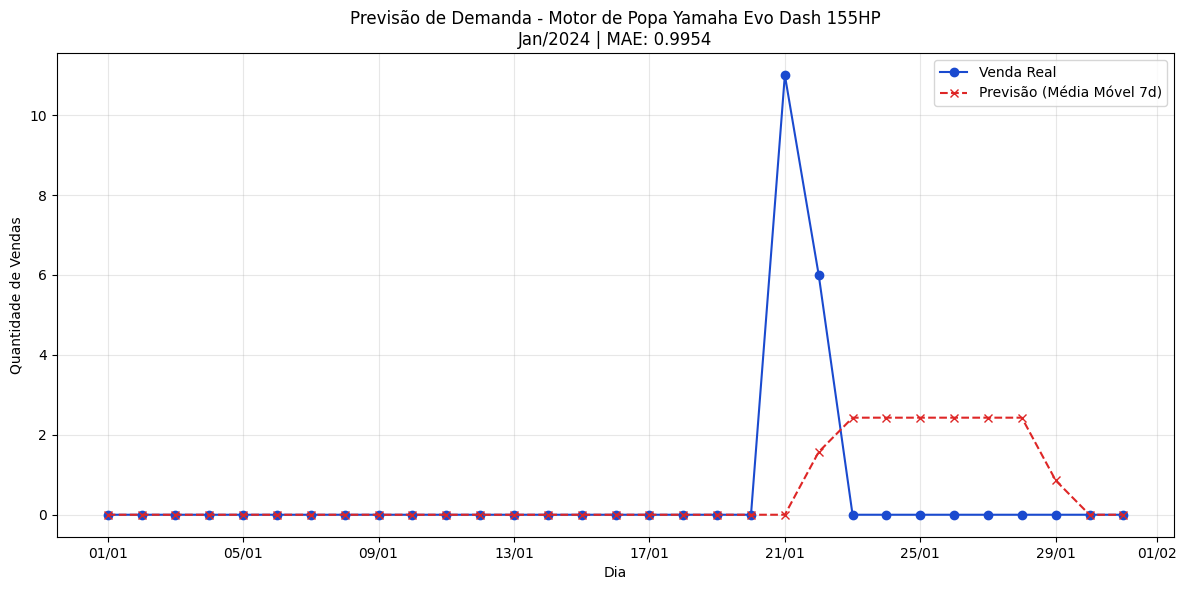

In [ ]:
# Gráfico
plt.figure(figsize=(12, 6))

plt.plot(teste['sale_date'], teste['qtd'], label='Venda Real', color="#1A4ACF", marker='o')
plt.plot(teste['sale_date'], teste['previsao'], label='Previsão (Média Móvel 7d)', color="#DE2626", linestyle='--', marker='x')

# Formatação do eixo X (Datas)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.title(f'Previsão de Demanda - Motor de Popa Yamaha Evo Dash 155HP\nJan/2024 | MAE: {mae:.4f}')
plt.xlabel('Dia')
plt.ylabel('Quantidade de Vendas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('../notebooks/graficos/grafico_previsao.png')
plt.show()